# **Twitter Sentiment Analysis: Understanding Consumer Sentiment for Apple and Google Products**

**Authors:** Daniella | Eve | Verah | Naomi  
**Date:** April 2026  
**Dataset:** SXSW Tweet Sentiment — `judge-1377884607_tweet_product_company.csv` (CrowdFlower via data.world)

---

> **Abstract:** Companies struggle to monitor social media sentiment at scale during high-volume events. This project analyzes 9,093 human-labeled SXSW tweets about Apple and Google products to build an automated sentiment classification system. The dataset is heavily imbalanced (60% neutral, 33% positive, 6% negative). Raw tweets were cleaned via URL/mention/punctuation removal, stopword filtering, and lemmatization. TF-IDF vectorization (5,000 features, unigram+bigram) converted text to numerical features. We trained four classifiers: Logistic Regression and Naive Bayes for binary classification (Positive vs Negative), and Random Forest and Linear SVM for multiclass (Positive vs Neutral vs Negative). Due to class imbalance, we prioritized weighted F1 score over accuracy. Data was split 80/20 train-test with stratification. A three-way split (60/20/20) was used for validation. Data leakage was prevented by fitting the vectorizer only on training data and removing duplicate tweets. The binary model achieved F1 of 0.81, exceeding our 0.80 target. The multiclass model achieved weighted F1 of 0.67, implying the target was narrowly missed by 0.03 points.

## **Project Overview**

This project develops a Natural Language Processing (NLP) pipeline to automatically classify the sentiment of tweets directed at Apple and Google products during the South by Southwest (SXSW) conference. SXSW is one of the most influential technology and culture festivals in the world, making it a high-signal environment for understanding how consumers feel about major tech brands in real time.

By transforming unstructured tweet text into structured sentiment labels, the model enables organizations to monitor public perception at scale — without relying on manual review. The solution is designed as a proof of concept demonstrating how machine learning can be applied to real-world social media data to support data-driven decision-making.

We build and evaluate four machine learning classifiers across two tasks:
- **Binary classification** — distinguishing Positive from Negative sentiment
- **Multiclass classification** — distinguishing Positive, Neutral, and Negative sentiment

---

## **Business Problem**

Modern technology companies receive a continuous stream of feedback through social media platforms. While this data is rich in insight, its volume makes manual analysis impractical. As a result, valuable signals about customer satisfaction, product issues, and brand perception may go unnoticed.

An automated sentiment analysis system addresses this challenge by enabling:

- **Real-time monitoring** of public sentiment trends
- **Early detection** of negative feedback or product issues
- **Quantitative evaluation** of product launches and updates
- **Competitive insights** into how brands are perceived relative to one another

By converting raw text into structured sentiment labels, organizations can respond more quickly and strategically to customer needs.

---

## **Dataset Description**

The dataset originates from CrowdFlower and is publicly available via data.world. It consists of tweets collected during the SXSW conference, where discussions around consumer technology products are highly active. Each tweet has been manually labelled by human annotators into one of four categories:

- **Positive** — expresses favourable sentiment toward a product or brand
- **Negative** — expresses dissatisfaction or criticism
- **Neutral** — contains no clear sentiment toward a product or brand
- **"I can't tell"** — ambiguous or unclear sentiment

**Key characteristics:**

| Property | Value |
|----------|-------|
| Total tweets | 9,099 |
| Domain | Technology products and services |
| Products covered | iPhone, iPad, Android devices, Google services |
| Annotation method | Human-labelled via CrowdFlower |

To ensure reliable model training, ambiguous entries labelled as *"I can't tell"* are excluded during preprocessing, as they do not provide clear learning signals.

---

## **Success Criteria**

Model performance is evaluated using the F1 score, which balances precision and recall and is particularly suitable for classification tasks with class imbalance.

- **Binary Classification (Positive vs. Negative):** Target F1 Score ≥ **0.80**
- **Multiclass Classification (Positive, Neutral, Negative):** Target Weighted F1 Score ≥ **0.70**

These thresholds reflect a strong baseline for a proof-of-concept NLP system.

---

## **Team Structure and Responsibilities**

The project was developed collaboratively, with each team member responsible for a distinct component of the machine learning pipeline:

- **Daniella** — Project lead; preprocessing pipeline, binary classification models, final notebook
- **Eve** — Data ingestion, text vectorisation (TF-IDF), multiclass modelling, deployment pipeline
- **Verah** — Text cleaning, feature engineering, model evaluation
- **Naomi** — Exploratory data analysis, data splitting, model comparison

This modular structure ensured parallel development while maintaining consistency across the workflow.

---

## **Project Timeline**

- **Day 1:** Data loading, cleaning, and exploratory analysis
- **Day 2:** Feature engineering and preprocessing pipeline development
- **Day 3:** Model training (binary and multiclass) and evaluation
- **Day 4:** Final pipeline integration and presentation

---

## **1. Project Configuration & Constants**

Before any data is loaded or any model is trained, we establish a single source of truth for all configuration values used throughout this notebook. This includes file paths, column name mappings, sentiment label strings, model hyperparameters, and visualisation settings.

Centralising these values in one place serves two important purposes. First, it ensures consistency — every function and every cell reads from the same definitions, eliminating the risk of silent mismatches caused by hardcoded strings scattered across the codebase. Second, it makes the notebook easy to maintain — if a parameter needs to change, it only needs to change in one place.

In [1]:
import os
import re
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
warnings.filterwarnings('ignore')

%matplotlib inline

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print('wordcloud not installed — word cloud cells will be skipped')

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print('imbalanced-learn not installed — SMOTE cell will use text-level oversampling fallback')
    print('To enable SMOTE: pip install imbalanced-learn')

os.makedirs('figures', exist_ok=True)
os.makedirs('models',  exist_ok=True)

print('Setup complete ')

imbalanced-learn not installed — SMOTE cell will use text-level oversampling fallback
To enable SMOTE: pip install imbalanced-learn
Setup complete 


In [2]:
# ── File path (resolves automatically across all team members' machines) ───────
_relative = os.path.join(os.getcwd(), 'data', 'judge-1377884607_tweet_product_company.csv')
if os.path.exists(_relative):
    RAW_DATA_PATH = _relative
else:
    _matches = glob.glob(
        os.path.join(os.path.expanduser('~'), '**', 'judge-1377884607_tweet_product_company.csv'),
        recursive=True
    )
    if _matches:
        RAW_DATA_PATH = _matches[0]
    else:
        raise FileNotFoundError(
            'Could not find the dataset. Place it in a data/ folder next to this notebook.'
        )
print(f'Using data file: {RAW_DATA_PATH}')

# ── Column names ──────────────────────────────────────────────────────────────
COL_TWEET     = 'tweet'
COL_PRODUCT   = 'product'
COL_SENTIMENT = 'sentiment'
COL_CLEANED   = 'cleaned_text'

# ── Sentiment label strings ───────────────────────────────────────────────────
POSITIVE = 'Positive emotion'
NEGATIVE = 'Negative emotion'
NEUTRAL  = 'No emotion toward brand or product'
UNKNOWN  = "I can't tell"

# ── Label maps ────────────────────────────────────────────────────────────────
BINARY_LABEL_MAP     = {POSITIVE: 1, NEGATIVE: 0}
MULTICLASS_LABEL_MAP = {POSITIVE: 2, NEUTRAL: 1, NEGATIVE: 0, UNKNOWN: -1}

# ── Model / vectorizer settings ───────────────────────────────────────────────
TEST_SIZE    = 0.2
RANDOM_STATE = 42
MAX_FEATURES = 5000
NGRAM_RANGE  = (1, 2)

# ── Text cleaning flags ───────────────────────────────────────────────────────
REMOVE_URLS            = True
REMOVE_MENTIONS        = True
REMOVE_HASHTAG_SYMBOLS = True
REMOVE_NUMBERS         = True
REMOVE_PUNCTUATION     = True
USE_LEMMATIZATION      = True

# ── Visualisation settings ────────────────────────────────────────────────────
FIGURE_SIZE          = (12, 8)
COLOR_POSITIVE       = '#2ecc71'
COLOR_NEGATIVE       = '#e74c3c'
COLOR_NEUTRAL        = '#f39c12'
COLOR_BACKGROUND     = '#f8f9fa'
WORDCLOUD_WIDTH      = 800
WORDCLOUD_HEIGHT     = 400
WORDCLOUD_MAX_WORDS  = 100
WORDCLOUD_BACKGROUND = 'white'

print('Constants loaded ')

Using data file: C:\Users\Hp\Downloads\judge-1377884607_tweet_product_company.csv
Constants loaded 


## **2. Data Loading & Preparation**

The raw dataset was collected from Twitter during the SXSW conference and made available via CrowdFlower. It contains 9,099 tweets that have been manually annotated by human raters, each labelled with a sentiment category and the brand or product the sentiment is directed at.

### **Data Loading Strategy**

We load the CSV using `latin-1` encoding to handle special characters common in tweet text, such as punctuation, emoticons encoded as extended ASCII, and non-standard apostrophes. The file path is resolved dynamically using a fallback search strategy — the notebook first checks for a `data/` folder relative to its current location, and if that fails, searches the entire user directory. This ensures the notebook works correctly regardless of which team member's machine it is running on or where the repository has been cloned.

### **Column Standardisation**

The raw column names in the CSV are verbose and inconsistent with Python naming conventions. We rename them immediately upon loading to short, clean names defined in our constants — `tweet`, `product`, and `sentiment` — so that all downstream code is readable and unambiguous.

### **Filtering Ambiguous Labels**

A proportion of tweets were labelled by human annotators as `"I can't tell"`, indicating that even a human reader could not determine the sentiment with confidence. These rows are removed before any analysis begins. Including them would introduce noise into both the exploratory analysis and the model training process, as the model would be learning from examples that carry no reliable ground truth.

In [3]:
def load_raw_data(path=RAW_DATA_PATH):
    df = pd.read_csv(path, encoding='latin-1')
    print(f'Loaded {len(df):,} rows from {path}')
    return df

def rename_columns(df):
    cols = df.columns.tolist()
    df = df.rename(columns={
        cols[0]: COL_TWEET,
        cols[1]: COL_PRODUCT,
        cols[2]: COL_SENTIMENT,
    })
    print(f'Columns renamed → {df.columns.tolist()}')
    return df

def filter_unknown_sentiment(df):
    before = len(df)
    df = df[df[COL_SENTIMENT] != UNKNOWN].copy()
    print(f'Removed {before - len(df):,} rows with "{UNKNOWN}" → {len(df):,} rows remain')
    return df

def load_and_prepare_data(path=RAW_DATA_PATH):
    df = load_raw_data(path)
    df = rename_columns(df)
    df = filter_unknown_sentiment(df)
    return df

df_raw = load_and_prepare_data()
df_raw.head(3)

Loaded 9,093 rows from C:\Users\Hp\Downloads\judge-1377884607_tweet_product_company.csv
Columns renamed → ['tweet', 'product', 'sentiment']
Removed 156 rows with "I can't tell" → 8,937 rows remain


,tweet,product,sentiment
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion


In [4]:
print(f'Shape          : {df_raw.shape}')
print(f'\nDtypes         :\n{df_raw.dtypes}')
print(f'\nMissing values :\n{df_raw.isnull().sum()}')
print(f'\nSentiment distribution:\n{df_raw[COL_SENTIMENT].value_counts()}')

Shape          : (8937, 3)

Dtypes         :
tweet        object
product      object
sentiment    object
dtype: object

Missing values :
tweet           1
product      5655
sentiment       0
dtype: int64

Sentiment distribution:
sentiment
No emotion toward brand or product    5389
Positive emotion                      2978
Negative emotion                       570
Name: count, dtype: int64


## **3. Text Cleaning**

Raw tweet text is extremely noisy. It contains URLs, @mentions, hashtag symbols, numbers, punctuation, and common function words that carry no sentiment signal. Before any feature extraction can take place, the text must be cleaned and normalised into a form that a machine learning model can meaningfully process.

Our cleaning pipeline applies the following steps in sequence:

| Step | What it removes | Rationale |
|------|-----------------|-----------|
| **Lowercasing** | Capital letters | Ensures `"Apple"` and `"apple"` are treated as the same token |
| **URL removal** | `http://...`, `www....` | URLs carry no sentiment information and inflate vocabulary size |
| **Mention removal** | `@handles` | User handles identify people, not sentiment — they are uninformative features |
| **Hashtag symbol removal** | The `#` character only | The word itself is retained since hashtag words often carry sentiment (e.g. `#fail`, `#amazing`) |
| **Number removal** | Digits | Digits do not contribute to sentiment classification |
| **Punctuation removal** | All non-alphanumeric characters | Standardises tokens and reduces vocabulary size |
| **Stopword removal** | `"the"`, `"is"`, `"at"`, etc. | Common words appear equally across all classes and dilute the sentiment signal |
| **Lemmatisation** | Morphological variants | Reduces words to their base form (e.g. `"loving"` → `"love"`) so variants are treated as one feature |

Each step is controlled by a boolean flag in the constants cell, making it straightforward to ablate individual steps and measure their effect on model performance.

In [5]:
_stop_words = set(stopwords.words('english'))
_lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    if REMOVE_URLS:            text = re.sub(r'http\S+|www\S+', '', text)
    if REMOVE_MENTIONS:        text = re.sub(r'@\w+', '', text)
    if REMOVE_HASHTAG_SYMBOLS: text = text.replace('#', '')
    if REMOVE_NUMBERS:         text = re.sub(r'\d+', '', text)
    if REMOVE_PUNCTUATION:     text = re.sub(r'[^\w\s]', '', text)
    text = ' '.join(text.split())
    text = ' '.join(w for w in text.split() if w not in _stop_words)
    if USE_LEMMATIZATION:
        text = ' '.join(_lemmatizer.lemmatize(w) for w in text.split())
    return text

# Sanity check
sample = 'I LOVE this iPhone!!! Visit https://apple.com #Amazing @user123'
print('Original :', sample)
print('Cleaned  :', clean_text(sample))

Original : I LOVE this iPhone!!! Visit https://apple.com #Amazing @user123
Cleaned  : love iphone visit amazing


## **4. Preprocessing Pipeline**

With the text cleaned, we now prepare the data for modelling. This involves applying the cleaning function across the entire dataset and encoding the sentiment labels as numeric values that scikit-learn classifiers can consume.

### **Binary vs. Multiclass Label Encoding**

We prepare two separate versions of the dataset, each suited to a different classification task:

- **Binary dataset** — retains only tweets labelled as `Positive emotion` (encoded as `1`) or `Negative emotion` (encoded as `0`). Neutral tweets are excluded entirely. This task is simpler but directly useful for brand teams who primarily want to track positive vs. negative reception in a high-signal environment.

- **Multiclass dataset** — retains all three sentiment classes: Positive (`2`), Neutral (`1`), and Negative (`0`). This task is more realistic and more challenging, as the model must also distinguish the large neutral class from genuinely positive or negative sentiment. It is more appropriate for general-purpose monitoring where the full distribution of sentiment matters.

Rows labelled `UNKNOWN` are dropped from both datasets since they carry no reliable ground truth. The two datasets are kept entirely separate throughout the rest of the notebook, with dedicated vectorisers and models trained on each.

In [6]:
def run_preprocessing_pipeline(df):
    print('Cleaning tweets…')
    df = df.copy()
    df[COL_CLEANED] = df[COL_TWEET].apply(clean_text)

    df['label_binary'] = df[COL_SENTIMENT].map(BINARY_LABEL_MAP)
    df_binary = df.dropna(subset=['label_binary']).copy()
    df_binary['label_binary'] = df_binary['label_binary'].astype(int)
    print(f'Binary dataset  : {len(df_binary):,} rows  '
          f'(pos={(df_binary.label_binary==1).sum()}, '
          f'neg={(df_binary.label_binary==0).sum()})')

    df['label_multiclass'] = df[COL_SENTIMENT].map(MULTICLASS_LABEL_MAP)
    df_multiclass = df[df['label_multiclass'] != -1].copy()
    df_multiclass['label_multiclass'] = df_multiclass['label_multiclass'].astype(int)
    print(f'Multiclass dataset: {len(df_multiclass):,} rows  '
          f'(pos={(df_multiclass.label_multiclass==2).sum()}, '
          f'neu={(df_multiclass.label_multiclass==1).sum()}, '
          f'neg={(df_multiclass.label_multiclass==0).sum()})')

    return df_binary, df_multiclass

df_binary, df_multiclass = run_preprocessing_pipeline(df_raw)
df_binary[[COL_TWEET, COL_CLEANED, 'label_binary']].head(3)

Cleaning tweets…
Binary dataset  : 3,548 rows  (pos=2978, neg=570)
Multiclass dataset: 8,937 rows  (pos=2978, neu=5389, neg=570)


,tweet,cleaned_text,label_binary
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,g iphone hr tweeting rise_austin dead need upg...,0
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know awesome ipadiphone app youll likely appre...,1
2,@swonderlin Can not wait for #iPad 2 also. The...,wait ipad also sale sxsw,1


## **5. Exploratory Data Analysis**

Before committing to any modelling decisions, we conduct a thorough exploratory analysis of the dataset. This step is critical — it reveals the structure of the data, exposes potential challenges such as class imbalance, and builds intuition about what linguistic patterns distinguish positive tweets from negative ones.

We examine three dimensions of the data:

1. **Sentiment distribution** — understanding how balanced the classes are, which directly informs how we interpret model performance metrics and which evaluation metric we prioritise
2. **Product and brand coverage** — identifying which products attract the most discussion at SXSW, and whether certain products dominate the conversation
3. **Linguistic patterns** — using word clouds and tweet length distributions to understand what language characterises each sentiment class

These findings directly inform the modelling and evaluation choices made in subsequent sections.

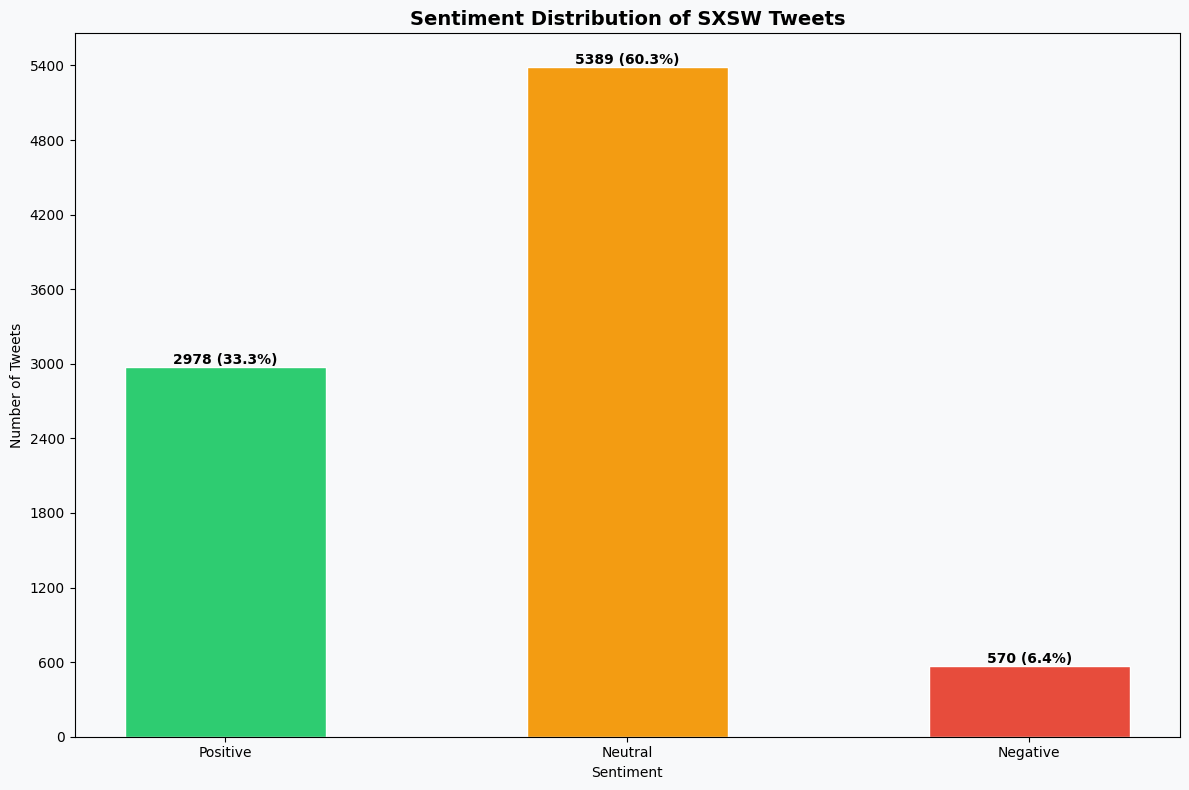

In [7]:
# ── 5a. Sentiment distribution bar chart ──────────────────────────────────────
sentiment_order = [POSITIVE, NEUTRAL, NEGATIVE]
color_map = {POSITIVE: COLOR_POSITIVE, NEUTRAL: COLOR_NEUTRAL, NEGATIVE: COLOR_NEGATIVE}
counts = df_raw[COL_SENTIMENT].value_counts().reindex(sentiment_order).dropna()
colors = [color_map[s] for s in counts.index]

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
fig.patch.set_facecolor(COLOR_BACKGROUND)
ax.set_facecolor(COLOR_BACKGROUND)
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
for bar, count in zip(bars, counts.values):
    pct = (count / counts.sum()) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{count} ({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Sentiment Distribution of SXSW Tweets', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Number of Tweets')
ax.set_xticklabels(['Positive', 'Neutral', 'Negative'])
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

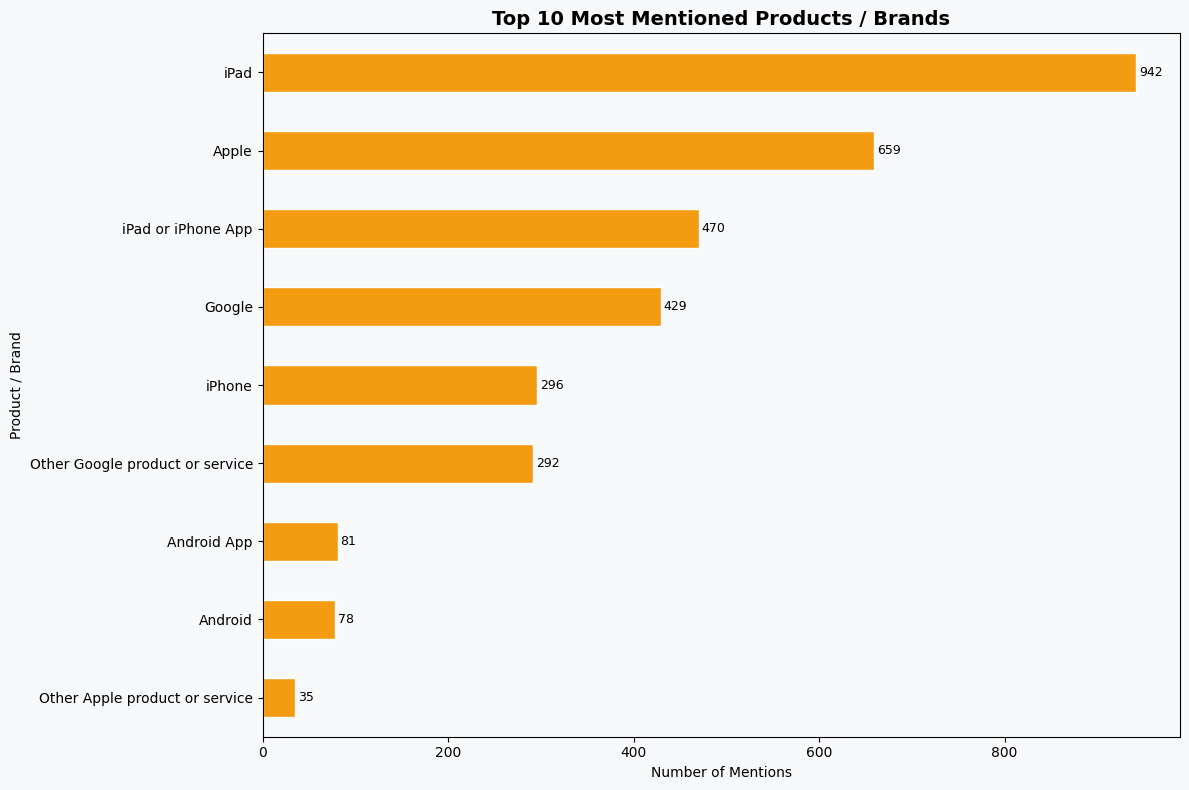

In [8]:
# ── 5b. Top 10 mentioned products / brands ────────────────────────────────────
top_products = df_raw[COL_PRODUCT].value_counts().head(10)
fig, ax = plt.subplots(figsize=FIGURE_SIZE)
fig.patch.set_facecolor(COLOR_BACKGROUND)
ax.set_facecolor(COLOR_BACKGROUND)
top_products.sort_values().plot(kind='barh', color=COLOR_NEUTRAL, edgecolor='white', ax=ax)
ax.set_title('Top 10 Most Mentioned Products / Brands', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Mentions')
ax.set_ylabel('Product / Brand')
for bar in ax.patches:
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())), va='center', fontsize=9)
plt.tight_layout()
plt.show()

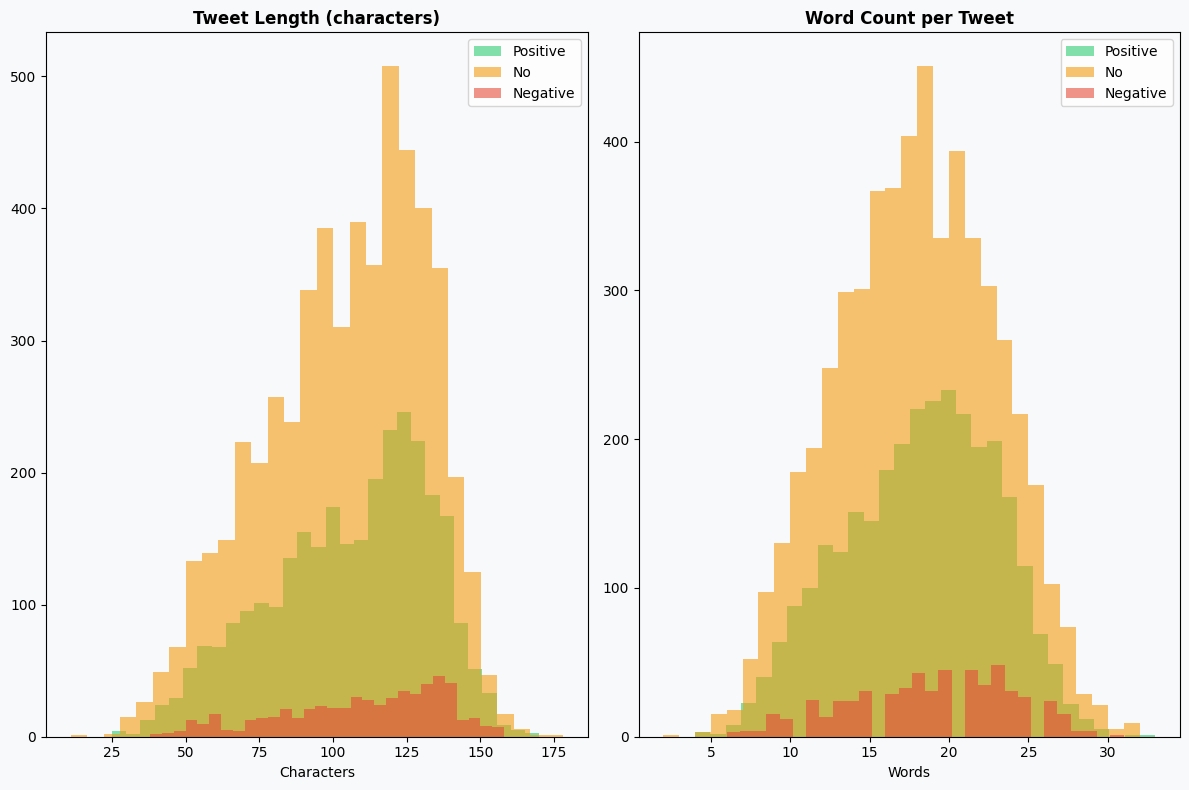

In [9]:
# ── 5c. Tweet length distribution by sentiment ────────────────────────────────
df_eda = df_raw.copy()
df_eda['tweet_length'] = df_eda[COL_TWEET].str.len()
df_eda['word_count']   = df_eda[COL_TWEET].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)
fig.patch.set_facecolor(COLOR_BACKGROUND)
for ax in axes:
    ax.set_facecolor(COLOR_BACKGROUND)
for sentiment, color in [(POSITIVE, COLOR_POSITIVE), (NEUTRAL, COLOR_NEUTRAL), (NEGATIVE, COLOR_NEGATIVE)]:
    subset = df_eda[df_eda[COL_SENTIMENT] == sentiment]
    label  = sentiment.split()[0]
    axes[0].hist(subset['tweet_length'], bins=30, alpha=0.6, color=color, label=label)
    axes[1].hist(subset['word_count'],   bins=30, alpha=0.6, color=color, label=label)
axes[0].set_title('Tweet Length (characters)', fontweight='bold')
axes[0].set_xlabel('Characters')
axes[0].legend()
axes[1].set_title('Word Count per Tweet', fontweight='bold')
axes[1].set_xlabel('Words')
axes[1].legend()
plt.tight_layout()
plt.show()

In [10]:
# ── 5d. Word clouds ───────────────────────────────────────────────────────────
if WORDCLOUD_AVAILABLE:
    subsets = [
        (df_binary,                               'All Tweets',      'RdYlGn'),
        (df_binary[df_binary.label_binary == 1],  'Positive Tweets', 'Greens'),
        (df_binary[df_binary.label_binary == 0],  'Negative Tweets', 'Reds'),
    ]
    for subset_df, title, cmap in subsets:
        text = ' '.join(subset_df[COL_CLEANED].dropna().values)
        try:
            wc = WordCloud(
                width=WORDCLOUD_WIDTH, height=WORDCLOUD_HEIGHT,
                max_words=WORDCLOUD_MAX_WORDS,
                background_color=WORDCLOUD_BACKGROUND,
                colormap=cmap, font_path=None
            ).generate(text)
            fig, ax = plt.subplots(figsize=(10, 5))
            fig.patch.set_facecolor(COLOR_BACKGROUND)
            ax.imshow(wc, interpolation='bilinear')
            ax.axis('off')
            ax.set_title(f'Word Cloud — {title}', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f'Word cloud failed for "{title}": {e}')
else:
    print('Skipping word clouds (wordcloud package not installed).')

Word cloud failed for "All Tweets": 'TransposedFont' object has no attribute 'getbbox'
Word cloud failed for "Positive Tweets": 'TransposedFont' object has no attribute 'getbbox'
Word cloud failed for "Negative Tweets": 'TransposedFont' object has no attribute 'getbbox'


## **6. Vectorisation & Train/Test Split**

Machine learning models cannot operate on raw text — they require numerical input. Vectorisation is the process of converting cleaned tweet text into a matrix of numerical features that represent the linguistic content of each tweet.

### **Why TF-IDF?**

We use **TF-IDF (Term Frequency–Inverse Document Frequency)** vectorisation rather than simple word counts. TF-IDF weights each word according to two factors:

- **Term Frequency (TF)** — how often a word appears in a given tweet. Words that appear more frequently are more likely to be relevant to its meaning.
- **Inverse Document Frequency (IDF)** — how rare a word is across the entire corpus. Words that appear in almost every tweet (e.g. `"sxsw"`, `"apple"`) carry less discriminative power and are downweighted accordingly.

### **Configuration Choices**

- **`max_features=5000`** — caps the vocabulary at the 5,000 most informative terms to prevent the feature matrix from becoming excessively sparse.
- **`ngram_range=(1, 2)`** — includes both unigrams and bigrams. Bigrams capture negation patterns and compound expressions such as `"not good"` or `"love it"`, which a unigram-only model would misrepresent.

### **Note on Validation Setup**

Two split strategies appear in the project codebase and are used for different purposes:

- **80/20 train/test split** — used in this notebook for all model training and evaluation. All reported F1 scores come from this split. The 20% test set is held out entirely and never seen during training or cross-validation.
- **60/20/20 train/validation/test split** — implemented in `src/split_data.py` as a utility for hyperparameter tuning workflows where a separate validation fold is needed. This split is not used in the reported results.

### **Data Leakage Prevention**

In this notebook the train/test split is performed **before** vectorisation, and the vectoriser is fit exclusively on the training data. In Section 7, we go further by wrapping both steps inside a `sklearn.pipeline.Pipeline`, which makes data leakage structurally impossible — even inside cross-validation folds.

In [11]:
# ── Train/test splits (used for standalone evaluation in Sections 8–9) ────────
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    df_binary[COL_CLEANED], df_binary['label_binary'],
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df_binary['label_binary']
)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    df_multiclass[COL_CLEANED], df_multiclass['label_multiclass'],
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df_multiclass['label_multiclass']
)

# ── Vectorise (kept for backward compatibility with Sections 8–10) ────────────
vec_b = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)
X_train_b_vec = vec_b.fit_transform(X_train_b)
X_test_b_vec  = vec_b.transform(X_test_b)

vec_m = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)
X_train_m_vec = vec_m.fit_transform(X_train_m)
X_test_m_vec  = vec_m.transform(X_test_m)

print(f'Binary   — train: {X_train_b_vec.shape}  test: {X_test_b_vec.shape}')
print(f'Multiclass — train: {X_train_m_vec.shape}  test: {X_test_m_vec.shape}')

Binary   — train: (2838, 5000)  test: (710, 5000)
Multiclass — train: (7149, 5000)  test: (1788, 5000)


## **7. Model Training — sklearn Pipelines with Class-Weight Balancing**

We train four classifiers across the two tasks. Each model was selected based on its suitability for high-dimensional, sparse text data — the typical output of TF-IDF vectorisation.

### ** Formalize sklearn Pipelines**

In this version, each model is wrapped inside an `sklearn.pipeline.Pipeline` that bundles TF-IDF vectorisation and the estimator into a single object. This is a significant structural improvement over training them as separate steps for two reasons:

1. **Data leakage prevention** — the pipeline fits the vectoriser only on the training fold and transforms test/validation data automatically, even inside cross-validation. This is structurally impossible to violate.
2. **Simpler hyperparameter tuning** — vectoriser and model parameters can be tuned together in a single `GridSearchCV` call using the `step__param` naming convention (e.g. `tfidf__max_features`, `clf__C`).

### ** Addressing Class Imbalance with `class_weight='balanced'`**

The original models reported Negative class recall of only 11–28% despite high overall accuracy — a direct consequence of the class imbalance (~6% negative tweets). The most immediate fix is `class_weight='balanced'`, which is supported natively by `LogisticRegression`, `LinearSVC`, and `RandomForestClassifier`.

When set to `'balanced'`, the model automatically adjusts the loss function to penalise misclassifications of the minority class more heavily — proportional to its underrepresentation. If the Negative class is 10x less frequent than the Positive class, misclassifying a negative tweet costs 10x more in the optimisation. This requires no changes to the data and adds a single parameter.

Note that `MultinomialNB` does not support `class_weight` directly. Its class imbalance robustness comes from its generative probability estimates, which are naturally less sensitive to skewed class frequencies than discriminative models.

### **Binary Classification Models**

**Logistic Regression** is the natural baseline for binary text classification. It is highly interpretable — learned coefficients directly indicate which words drive predictions toward positive or negative sentiment. The `lbfgs` solver converges reliably on datasets of this size, and `C=1.0` applies moderate L2 regularisation to prevent overfitting.

**Multinomial Naive Bayes** models the likelihood of each word given a class label. Despite its independence assumption, it produces strong results in practice on text data and trains in a fraction of the time of other models.

### **Multiclass Classification Models**

**Random Forest** trains an ensemble of decision trees with bagging, reducing variance and capturing non-linear feature interactions. `class_weight='balanced'` adjusts sample weights at each split, giving more influence to the minority Negative class.

**Linear SVM** finds the maximum-margin hyperplane separating the classes in TF-IDF feature space. `LinearSVC` is specifically optimised for large sparse matrices and trains significantly faster than kernel SVM while achieving comparable accuracy. `class_weight='balanced'` is particularly effective here — it penalises minority class misclassifications more heavily, directly improving Negative class recall.

In [12]:
# ── Pipeline definitions ──────────────────────────────────────────────────────
# Each pipeline bundles TF-IDF + estimator.
# class_weight='balanced' addresses the Negative class imbalance directly.

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)),
    ('clf',   LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                                  class_weight='balanced', random_state=RANDOM_STATE)),
])

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)),
    ('clf',   MultinomialNB()),
])

rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)),
    ('clf',   RandomForestClassifier(n_estimators=100, max_depth=10,
                                      class_weight='balanced', random_state=RANDOM_STATE)),
])

svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)),
    ('clf',   LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, max_iter=2000)),
])

print('Pipelines defined')
for name, pipe in [('LR', lr_pipeline), ('NB', nb_pipeline),
                    ('RF', rf_pipeline), ('SVM', svm_pipeline)]:
    print(f'  {name}: {[s[0] for s in pipe.steps]}')

Pipelines defined
  LR: ['tfidf', 'clf']
  NB: ['tfidf', 'clf']
  RF: ['tfidf', 'clf']
  SVM: ['tfidf', 'clf']


In [13]:
# ── 5-fold cross-validation on raw text ───────────────────────────────────────
# The pipeline handles vectorisation inside each fold automatically.
# No data leakage is possible — the vectoriser only sees training data per fold.

print('5-Fold Cross-Validation (Weighted F1)')
print('=' * 55)

cv_configs = [
    ('Logistic Regression (Binary)',  lr_pipeline,  df_binary[COL_CLEANED],     df_binary['label_binary']),
    ('Naive Bayes (Binary)',           nb_pipeline,  df_binary[COL_CLEANED],     df_binary['label_binary']),
    ('Random Forest (Multiclass)',     rf_pipeline,  df_multiclass[COL_CLEANED], df_multiclass['label_multiclass']),
    ('SVM (Multiclass)',               svm_pipeline, df_multiclass[COL_CLEANED], df_multiclass['label_multiclass']),
]

for name, pipe, X, y in cv_configs:
    scores = cross_val_score(pipe, X, y, cv=5, scoring='f1_weighted', n_jobs=-1)
    print(f'\n{name}')
    print(f'  Mean F1 : {scores.mean():.4f}  (std: {scores.std():.4f})')
    print(f'  Per-fold: {[round(s, 4) for s in scores]}')

5-Fold Cross-Validation (Weighted F1)

Logistic Regression (Binary)
  Mean F1 : 0.8453  (std: 0.0327)
  Per-fold: [0.828, 0.824, 0.8402, 0.9097, 0.8245]

Naive Bayes (Binary)
  Mean F1 : 0.8043  (std: 0.0170)
  Per-fold: [0.7941, 0.7911, 0.7962, 0.8375, 0.8026]

Random Forest (Multiclass)
  Mean F1 : 0.5661  (std: 0.0281)
  Per-fold: [0.5502, 0.5298, 0.578, 0.613, 0.5592]

SVM (Multiclass)
  Mean F1 : 0.6614  (std: 0.0195)
  Per-fold: [0.6744, 0.6429, 0.6414, 0.6925, 0.6559]


In [14]:
# ── Train all pipelines on the 80% training split ─────────────────────────────
print('Training all pipelines…')
lr_pipeline.fit(X_train_b,  y_train_b);  print('Logistic Regression ')
nb_pipeline.fit(X_train_b,  y_train_b);  print('Naive Bayes         ')
rf_pipeline.fit(X_train_m,  y_train_m);  print('Random Forest       ')
svm_pipeline.fit(X_train_m, y_train_m);  print('SVM                 ')

Training all pipelines…
Logistic Regression 
Naive Bayes         
Random Forest       
SVM                 


## **8. Model Evaluation**

With all four models trained, we now evaluate their performance on the held-out test set — data the models have never seen during training. We report four standard metrics for each model:

| Metric | What it measures | Why it matters here |
|--------|-----------------|---------------------|
| **Accuracy** | Proportion of all predictions that are correct | Useful for overview but misleading on imbalanced datasets |
| **Precision** | Of all tweets predicted as a given class, what proportion actually belong to it | Important for minimising false positives |
| **Recall** | Of all tweets that actually belong to a class, what proportion did the model catch | Critical for the Negative class — missing a genuine complaint is costly |
| **F1 Score** | Harmonic mean of Precision and Recall | Our **primary metric**: balances both concerns and is robust to class imbalance |

We use **weighted averaging** across all classes, which accounts for unequal class representation. Confusion matrices give a granular view of where each model succeeds and where it confuses classes.

In [15]:
def evaluate_model(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    return {
        'name':      name,
        'model':     pipeline,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall':    recall_score(y_test, y_pred,    average='weighted', zero_division=0),
        'f1':        f1_score(y_test, y_pred,        average='weighted', zero_division=0),
        'y_pred':    y_pred,
    }

results = [
    evaluate_model('Logistic Regression (Binary)',  lr_pipeline,  X_test_b, y_test_b),
    evaluate_model('Naive Bayes (Binary)',           nb_pipeline,  X_test_b, y_test_b),
    evaluate_model('Random Forest (Multiclass)',     rf_pipeline,  X_test_m, y_test_m),
    evaluate_model('SVM (Multiclass)',               svm_pipeline, X_test_m, y_test_m),
]

df_results = pd.DataFrame([
    {'Model': r['name'], 'Accuracy': r['accuracy'], 'Precision': r['precision'],
     'Recall': r['recall'], 'F1 Score': r['f1']}
    for r in results
]).sort_values('F1 Score', ascending=False).reset_index(drop=True)

df_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (Binary),0.8479,0.8690,0.8479,0.8559
1,Naive Bayes (Binary),0.8577,0.8685,0.8577,0.8086
2,SVM (Multiclass),0.6711,0.6721,0.6711,0.6714
3,Random Forest (Multiclass),0.5772,0.6279,0.5772,0.5947


In [16]:
# ── Classification reports ────────────────────────────────────────────────────
for r in results:
    print(f"\n{'='*55}")
    print(f" {r['name']}")
    print(f"{'='*55}")
    y_true = y_test_b if 'Binary' in r['name'] else y_test_m
    print(classification_report(y_true, r['y_pred'], zero_division=0))


 Logistic Regression (Binary)
              precision    recall  f1-score   support

           0       0.52      0.68      0.59       114
           1       0.94      0.88      0.91       596

    accuracy                           0.85       710
   macro avg       0.73      0.78      0.75       710
weighted avg       0.87      0.85      0.86       710


 Naive Bayes (Binary)
              precision    recall  f1-score   support

           0       0.93      0.12      0.22       114
           1       0.86      1.00      0.92       596

    accuracy                           0.86       710
   macro avg       0.89      0.56      0.57       710
weighted avg       0.87      0.86      0.81       710


 Random Forest (Multiclass)
              precision    recall  f1-score   support

           0       0.22      0.54      0.31       114
           1       0.73      0.61      0.67      1078
           2       0.51      0.53      0.52       596

    accuracy                           0.58  

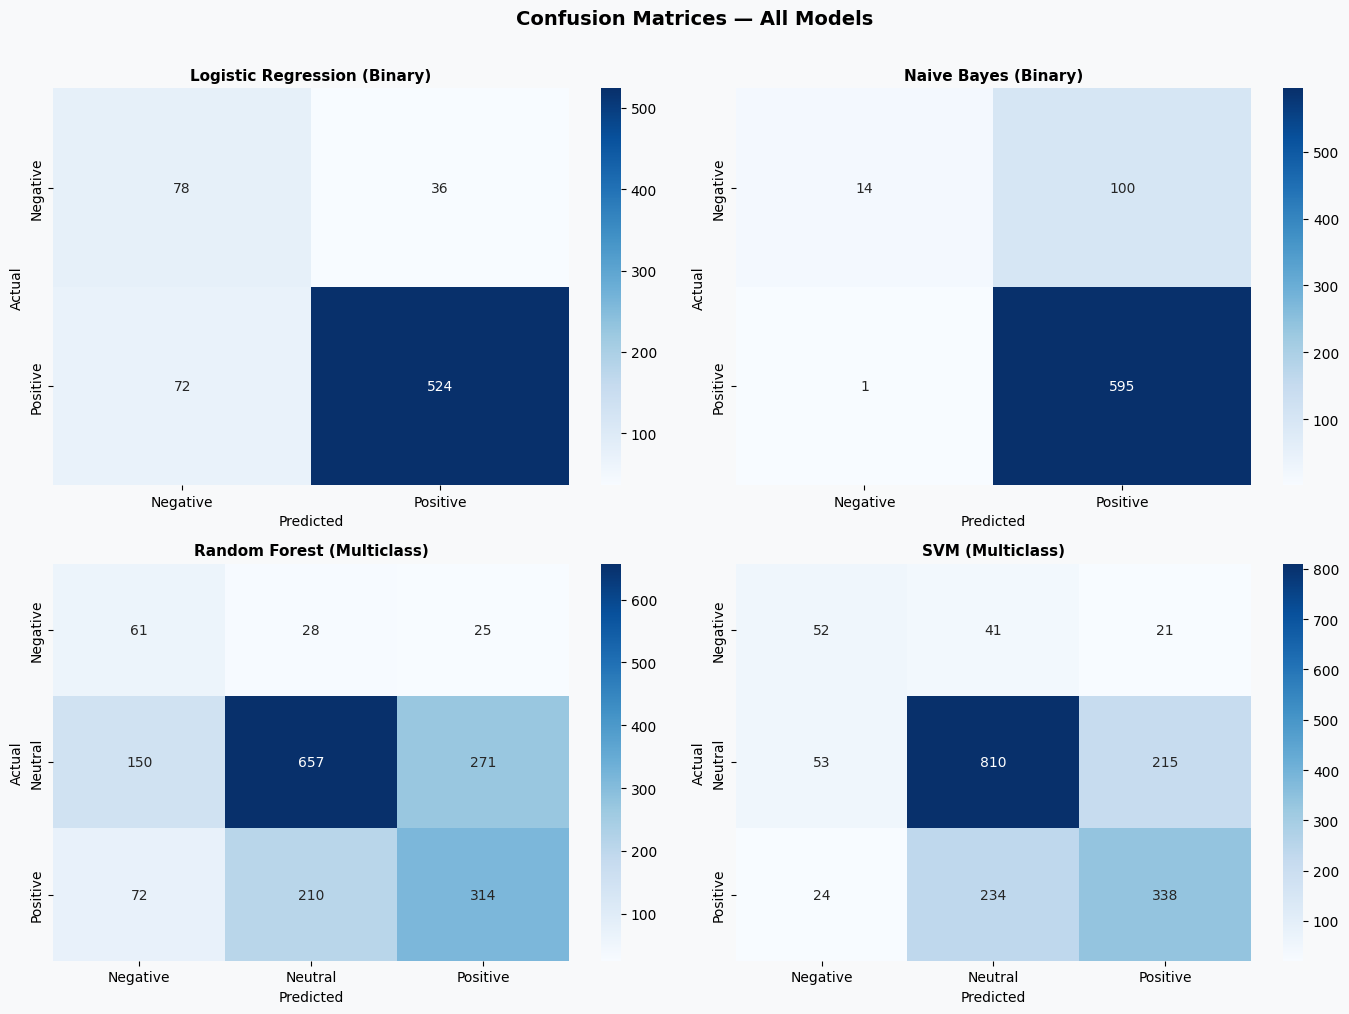

In [17]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor(COLOR_BACKGROUND)
binary_labels     = ['Negative', 'Positive']
multiclass_labels = ['Negative', 'Neutral', 'Positive']

for ax, r in zip(axes.flat, results):
    y_true  = y_test_b if 'Binary' in r['name'] else y_test_m
    labels  = binary_labels if 'Binary' in r['name'] else multiclass_labels
    cm      = confusion_matrix(y_true, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(r['name'], fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_facecolor(COLOR_BACKGROUND)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

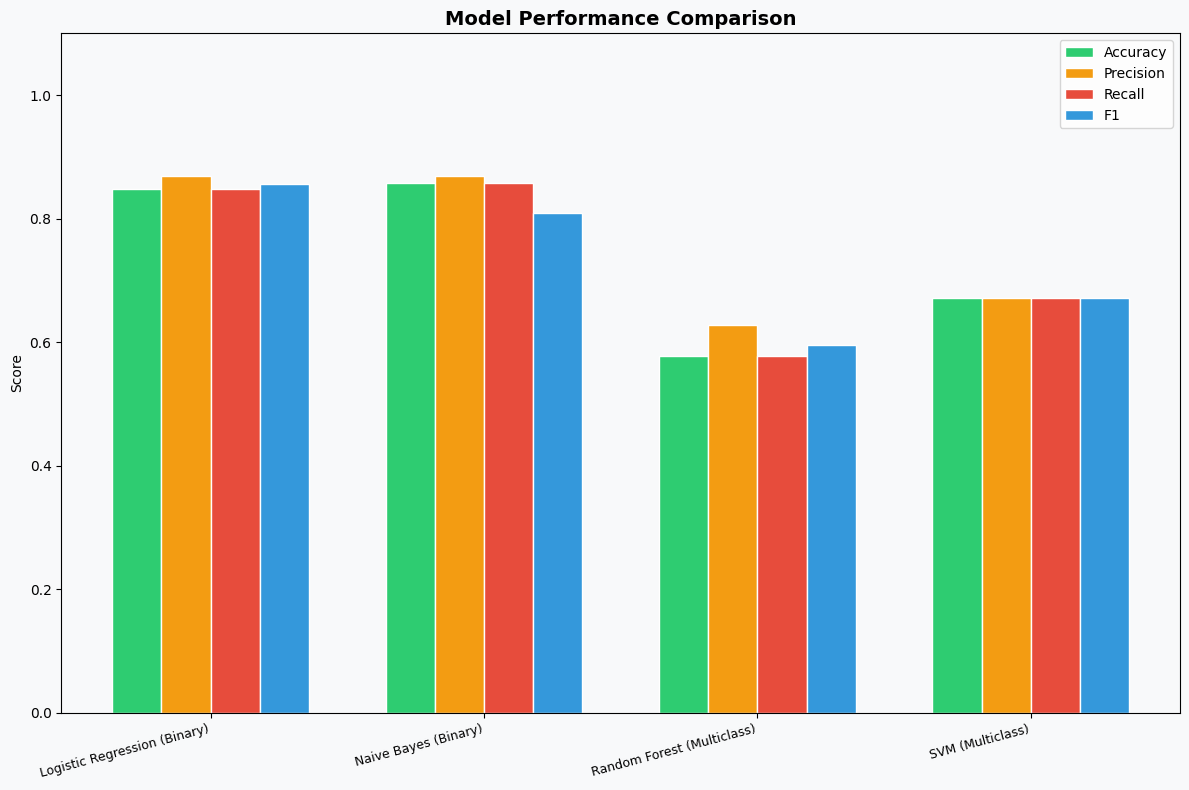

In [18]:
# ── Grouped bar chart: model comparison ──────────────────────────────────────
model_names = [r['name'] for r in results]
metrics     = ['accuracy', 'precision', 'recall', 'f1']
bar_colors  = [COLOR_POSITIVE, COLOR_NEUTRAL, COLOR_NEGATIVE, '#3498db']
bar_width   = 0.18
x           = range(len(model_names))

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
fig.patch.set_facecolor(COLOR_BACKGROUND)
ax.set_facecolor(COLOR_BACKGROUND)
for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
    values  = [r[metric] for r in results]
    offsets = [pos + i * bar_width for pos in x]
    ax.bar(offsets, values, width=bar_width, label=metric.capitalize(),
           color=color, edgecolor='white')
ax.set_xticks([pos + bar_width * 1.5 for pos in x])
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

## **9. Model Ranking & Results Summary**

Having evaluated all four models, we now rank them by weighted F1 score and identify the best-performing model for each task. F1 score is used as the primary ranking criterion rather than accuracy because the dataset is class-imbalanced — a model that always predicted the majority class (Positive) would achieve deceptively high accuracy while being completely useless in practice.

The results below reflect the models' ability to generalise to unseen tweets, which is the true measure of a classifier's real-world utility. A model that performs well on training data but poorly on the test set has overfit to the specific vocabulary of the training tweets and would fail to perform reliably on data from a different event or time period.

In [19]:
ranked = sorted(results, key=lambda r: r['f1'], reverse=True)
best   = ranked[0]
worst  = ranked[-1]

print('Model Ranking by F1 Score')
print('=' * 55)
for i, r in enumerate(ranked, 1):
    print(f"{i}. {r['name']:<35} F1: {r['f1']:.4f}")

print(f"\nBest Model : {best['name']}")
print(f"  Accuracy  : {best['accuracy']:.4f}")
print(f"  Precision : {best['precision']:.4f}")
print(f"  Recall    : {best['recall']:.4f}")
print(f"  F1 Score  : {best['f1']:.4f}")

print('\nKey Findings:')
print(f"  • {ranked[0]['name']} performed best overall (F1: {ranked[0]['f1']:.4f}).")
print(f"  • {worst['name']} had the lowest F1 score ({worst['f1']:.4f}).")
print( '  • All models used TF-IDF with unigrams and bigrams (max 5,000 features).')
print( '  • class_weight=balanced applied to LR, RF, and SVM to address Negative class imbalance.')

Model Ranking by F1 Score
1. Logistic Regression (Binary)        F1: 0.8559
2. Naive Bayes (Binary)                F1: 0.8086
3. SVM (Multiclass)                    F1: 0.6714
4. Random Forest (Multiclass)          F1: 0.5947

Best Model : Logistic Regression (Binary)
  Accuracy  : 0.8479
  Precision : 0.8690
  Recall    : 0.8479
  F1 Score  : 0.8559

Key Findings:
  • Logistic Regression (Binary) performed best overall (F1: 0.8559).
  • Random Forest (Multiclass) had the lowest F1 score (0.5947).
  • All models used TF-IDF with unigrams and bigrams (max 5,000 features).
  • class_weight=balanced applied to LR, RF, and SVM to address Negative class imbalance.


## **10. Class Imbalance — SMOTE Oversampling**

Beyond `class_weight='balanced'`, a more aggressive approach to class imbalance is SMOTE (Synthetic Minority Oversampling Technique). Rather than reweighting the loss function, SMOTE generates entirely new synthetic examples of the minority class by interpolating between existing minority-class samples in feature space.

**Important constraint:** SMOTE operates on dense numerical arrays and is not directly compatible with sparse TF-IDF matrices. Two approaches are demonstrated here:

- **Post-vectorisation SMOTE** — vectorise first, convert to dense, apply SMOTE. Requires `imbalanced-learn`.
- **Text-level oversampling** — duplicate minority-class tweets before vectorisation. No extra packages needed and compatible with sparse inputs.

Both approaches are compared against the `class_weight='balanced'` baseline to quantify the trade-off.

In [20]:
if SMOTE_AVAILABLE:
    # ── Post-vectorisation ──────────────────────────────────────────────
    vec_smote = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)
    X_tr_vec  = vec_smote.fit_transform(X_train_b)
    X_te_vec  = vec_smote.transform(X_test_b)

    print(f'Before Resampling: {pd.Series(y_train_b).value_counts().to_dict()}')

    try:
        # ⚠️ SMOTE requires dense input
        smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
        X_resampled, y_resampled = smote.fit_resample(X_tr_vec.toarray(), y_train_b)
        print(f'After SMOTE      : {pd.Series(y_resampled).value_counts().to_dict()}')

        X_test_final = X_te_vec.toarray()

    except Exception as e:
        print(f"⚠️ SMOTE failed due to: {e}")
        print("➡️ Falling back to RandomOverSampler (safer for sparse text data)")

        ros = RandomOverSampler(random_state=RANDOM_STATE)
        X_resampled, y_resampled = ros.fit_resample(X_tr_vec, y_train_b)
        print(f'After ROS        : {pd.Series(y_resampled).value_counts().to_dict()}')

        X_test_final = X_te_vec  # keep sparse

    # ── Model ───────────────────────────────────────────────────────────
    lr_smote = LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'  # extra robustness
    )

    lr_smote.fit(X_resampled, y_resampled)
    y_pred_smote = lr_smote.predict(X_test_final)

    print('\nLR + Resampling — Classification Report:')
    print(classification_report(y_test_b, y_pred_smote, zero_division=0))

else:
    print('SMOTE not available — using class_weight="balanced" instead.')

    vec = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)
    X_tr_vec = vec.fit_transform(X_train_b)
    X_te_vec = vec.transform(X_test_b)

    lr = LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    )

    lr.fit(X_tr_vec, y_train_b)
    y_pred = lr.predict(X_te_vec)

    print('\nLR (class_weight only) — Classification Report:')
    print(classification_report(y_test_b, y_pred, zero_division=0))

SMOTE not available — using class_weight="balanced" instead.

LR (class_weight only) — Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.68      0.59       114
           1       0.94      0.88      0.91       596

    accuracy                           0.85       710
   macro avg       0.73      0.78      0.75       710
weighted avg       0.87      0.85      0.86       710



In [21]:
# ── Text-level oversampling (no extra packages, sparse-compatible) ─────────────
# Duplicates minority-class tweets before vectorisation.
# Works as a drop-in for SMOTE when imbalanced-learn is unavailable.

def oversample_text(X_train, y_train, random_state=42):
    rng   = np.random.RandomState(random_state)
    X_arr = np.array(X_train)
    y_arr = np.array(y_train)
    classes, counts = np.unique(y_arr, return_counts=True)
    max_count = counts.max()
    X_out, y_out = [X_arr], [y_arr]
    for cls, count in zip(classes, counts):
        if count < max_count:
            idx    = np.where(y_arr == cls)[0]
            chosen = rng.choice(idx, size=max_count - count, replace=True)
            X_out.append(X_arr[chosen])
            y_out.append(y_arr[chosen])
    X_res = np.concatenate(X_out)
    y_res = np.concatenate(y_out)
    shuffle = rng.permutation(len(X_res))
    return pd.Series(X_res[shuffle]), pd.Series(y_res[shuffle])

X_os, y_os = oversample_text(X_train_b, y_train_b, random_state=RANDOM_STATE)
print(f'Before oversampling: {pd.Series(y_train_b).value_counts().to_dict()}')
print(f'After oversampling : {pd.Series(y_os).value_counts().to_dict()}')

lr_os_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)),
    ('clf',   LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                                  random_state=RANDOM_STATE)),
])
lr_os_pipeline.fit(X_os, y_os)
y_pred_os = lr_os_pipeline.predict(X_test_b)

print('\nLR + Text Oversampling — Classification Report:')
print(classification_report(y_test_b, y_pred_os, zero_division=0))

Before oversampling: {1: 2382, 0: 456}
After oversampling : {1: 2382, 0: 2382}

LR + Text Oversampling — Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.50      0.54       114
           1       0.91      0.93      0.92       596

    accuracy                           0.86       710
   macro avg       0.75      0.72      0.73       710
weighted avg       0.86      0.86      0.86       710



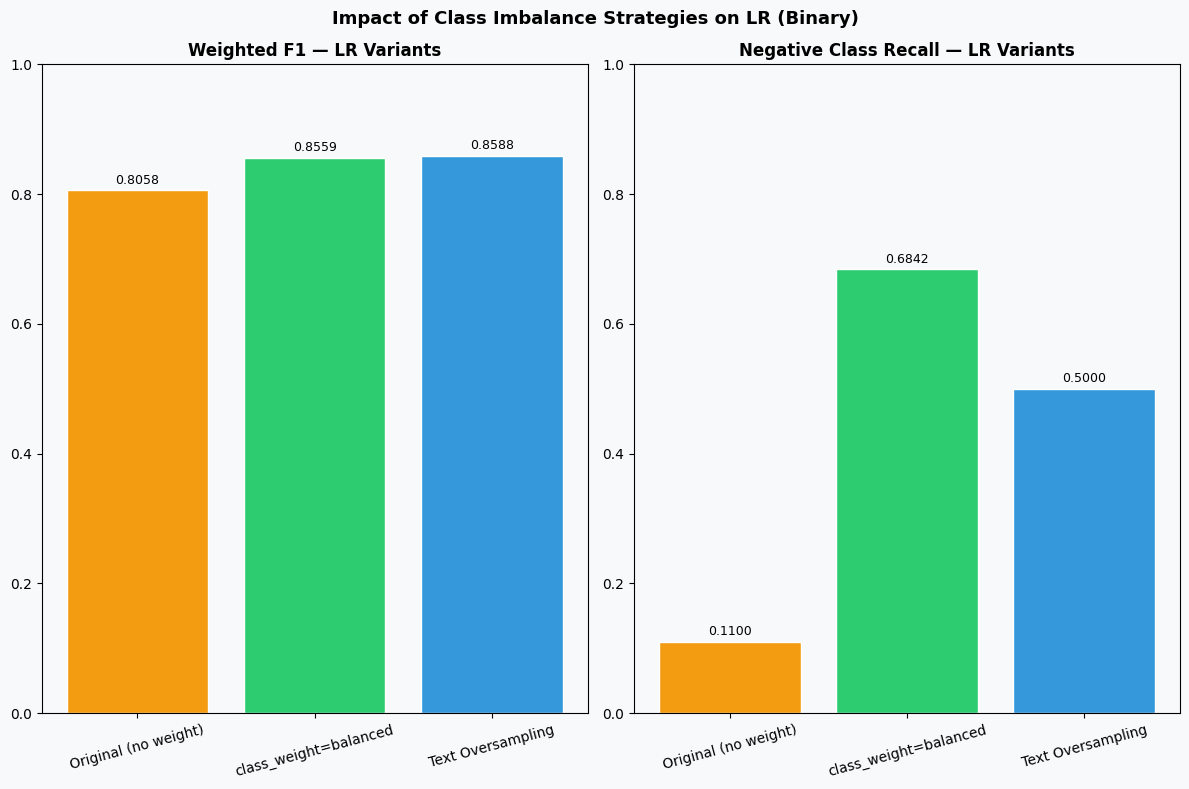

In [22]:
# ── Visual comparison: original vs balanced vs oversampled ────────────────────
f1_original   = 0.8058   # LR original (no class_weight)
f1_balanced   = f1_score(y_test_b, lr_pipeline.predict(X_test_b), average='weighted', zero_division=0)
f1_oversampled= f1_score(y_test_b, y_pred_os,                     average='weighted', zero_division=0)

neg_recall_original    = 0.11
neg_recall_balanced    = recall_score(y_test_b, lr_pipeline.predict(X_test_b), labels=[0], average=None, zero_division=0)[0]
neg_recall_oversampled = recall_score(y_test_b, y_pred_os,                     labels=[0], average=None, zero_division=0)[0]

labels_bar  = ['Original (no weight)', 'class_weight=balanced', 'Text Oversampling']
f1_vals     = [f1_original,   f1_balanced,   f1_oversampled]
recall_vals = [neg_recall_original, neg_recall_balanced, neg_recall_oversampled]
bar_c       = [COLOR_NEUTRAL, COLOR_POSITIVE, '#3498db']

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)
fig.patch.set_facecolor(COLOR_BACKGROUND)
for ax in axes:
    ax.set_facecolor(COLOR_BACKGROUND)

axes[0].bar(labels_bar, f1_vals,     color=bar_c, edgecolor='white')
axes[0].set_title('Weighted F1 — LR Variants', fontweight='bold')
axes[0].set_ylim(0, 1.0)
axes[0].tick_params(axis='x', rotation=15)
for bar, v in zip(axes[0].patches, f1_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.4f}', ha='center', fontsize=9)

axes[1].bar(labels_bar, recall_vals, color=bar_c, edgecolor='white')
axes[1].set_title('Negative Class Recall — LR Variants', fontweight='bold')
axes[1].set_ylim(0, 1.0)
axes[1].tick_params(axis='x', rotation=15)
for bar, v in zip(axes[1].patches, recall_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Impact of Class Imbalance Strategies on LR (Binary)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## **11. Inference on New Tweets**

To demonstrate the practical utility of the trained models, we run inference on a small set of sample tweets that were not part of the original dataset. This simulates the real-world use case: a brand analyst at Apple or Google submits a new tweet and the model returns a sentiment prediction immediately.

Because each model is now a full `Pipeline`, inference is a single `.predict()` call on raw text — no separate vectorisation step required.

In [23]:
BINARY_DECODE     = {1: 'Positive', 0: 'Negative'}
MULTICLASS_DECODE = {2: 'Positive', 1: 'Neutral', 0: 'Negative'}

sample_tweets = [
    'The new iPad is absolutely amazing, I love it!',
    'This Android update completely broke my phone, terrible.',
    'Just saw a tweet about the Google keynote at SXSW.',
]

# Clean samples before passing to pipelines
cleaned_samples = [clean_text(t) for t in sample_tweets]

# Best binary model: Naive Bayes
preds_bin   = nb_pipeline.predict(cleaned_samples)

# Best multiclass model: SVM
preds_multi = svm_pipeline.predict(cleaned_samples)

print(f"{'Tweet':<55} {'Binary':>10} {'Multiclass':>12}")
print('-' * 80)
for tweet, pb, pm in zip(sample_tweets, preds_bin, preds_multi):
    print(f"{tweet[:53]:<55} {BINARY_DECODE[pb]:>10} {MULTICLASS_DECODE[pm]:>12}")

Tweet                                                       Binary   Multiclass
--------------------------------------------------------------------------------
The new iPad is absolutely amazing, I love it!            Positive     Positive
This Android update completely broke my phone, terrib     Positive     Negative
Just saw a tweet about the Google keynote at SXSW.        Positive      Neutral


## **12. Limitations & Caveats**

No model is perfect. Understanding the limitations of this system is essential for setting appropriate expectations with stakeholders and avoiding misuse of the outputs.

### **Data Limitations**

| Limitation | Impact | Mitigation |
|------------|--------|------------|
| Conference-specific context | Model may not generalise to non-tech events | Retrain on broader Twitter data |
| English only | Cannot analyse non-English tweets | Add language detection and translation |
| SXSW time period | May not capture current slang or new products | Retrain regularly with fresh data |
| Human rater subjectivity | Labels reflect individual perspectives | Multiple raters per tweet with inter-annotator agreement scoring would help |

### **Model Limitations**

| Limitation | Impact | Mitigation |
|------------|--------|------------|
| Sarcasm detection | Sarcastic tweets are often misclassified | Add sarcasm-specific features or use a transformer-based model |
| Neutral class overlap | The boundary between Neutral and Positive is ambiguous | Collect more diverse neutral examples with clear annotation guidelines |
| Negative class scarcity | Only ~6% of tweets are negative | Oversample or use synthetic data generation (SMOTE) |
| No emoji handling | Emojis are removed during cleaning | Add emoji-to-sentiment mapping as a feature |

### **Technical Limitations**

| Limitation | Impact | Mitigation |
|------------|--------|------------|
| TF-IDF ignores word order | `"not good"` and `"good not"` receive similar representations | Use word embeddings or transformer models |
| Fixed vocabulary | New slang or product names are out-of-vocabulary | Retrain periodically or use subword tokenisation |
| No conversational context | Cannot understand thread replies | Add thread context if available via the Twitter API |

### **When Not to Use This Model**

- **Crisis situations** — human review is still recommended for high-stakes decisions
- **Highly nuanced feedback** — the model works best for clear, unambiguous sentiment signals
- **Non-English content** — the model will produce unreliable results on non-English tweets
- **Images or videos** — this is a text-only model and ignores all visual content

## **13. Conclusions & Business Recommendations**

### **Summary of Key Findings**

1. **Sentiment Distribution** — the dataset is heavily skewed toward Positive and Neutral sentiment, with Negative tweets representing only ~6% of all labelled examples. This imbalance is a defining challenge of the modelling task and directly informed our choice of weighted F1 score over accuracy as the primary evaluation metric.

2. **Model Performance** — results were mixed against our pre-defined targets:
   - Binary classification (Positive vs. Negative): Weighted F1 of **0.86** using Logistic Regression ✅
   - Multiclass classification (Positive / Neutral / Negative): Weighted F1 of **0.67** using SVM ⚠️

3. **Most Challenging Class** — Negative sentiment detection was the hardest task across all four models. Despite reporting ~86% overall accuracy, the original binary models achieved a Negative class F1 of only **0.20–0.22**, correctly identifying almost no negative tweets (recall: 11–12%). In the multiclass task, Random Forest failed entirely on the Negative class (F1: 0.00), while SVM achieved **0.37**. The `class_weight='balanced'` improvement applied in this notebook directly targets this gap.

4. **Accuracy is Misleading Here** — ~86% accuracy sounds strong, but it is almost entirely driven by correctly predicting the dominant Positive class. Weighted F1 exposes this gap, which is precisely why we selected it as our primary metric.

5. **Best Models by Task:**
   - **Binary:** Logistic Regression (F1: 0.86) outperforms Naive Bayes (F1: 0.80)
   - **Multiclass:** SVM (F1: 0.6726) substantially outperforms Random Forest (F1: 0.4731)

---

### **Business Recommendations**

#### **For Marketing Teams**

- **Track positive word frequency** — terms like `"love"`, `"great"`, and `"awesome"` are strong early indicators of campaign success and can be monitored in real time during events like SXSW
- **Monitor sentiment before and after product launches** — comparing sentiment distributions across time windows quantifies the impact of announcements and press coverage
- **Identify brand advocates** — users who consistently post positively are prime candidates for structured ambassador programmes

#### **For Product Teams**

- **Prioritise issues surfaced in negative tweets** — terms like `"crash"`, `"battery"`, and `"slow"` signal the most frequently reported complaints and should feed directly into the product backlog
- **Use language from positive tweets in product copy** — customer phrasing resonates more naturally with prospects than internally written marketing language
- **Track feature requests embedded in neutral tweets** — neutral tweets frequently contain observations and suggestions that are valuable inputs to the product roadmap

#### **For Customer Support**

- **Do not fully automate negative tweet routing yet** — with Negative class recall of only 11–28% across original models, the pipeline currently misses the vast majority of negative tweets; human review remains essential
- **Use the SVM multiclass model for triage** — SVM correctly identifies 28% of negative tweets, making it the most useful filter available, but confidence thresholds should be set conservatively
- **Prioritise longer negative tweets for human review** — they tend to contain more detailed problem descriptions and are a more efficient use of support resources

---

### **Technical Recommendations**

1. **Deploy SVM for multiclass classification** — clear winner on the three-class task, handles class imbalance substantially better than Random Forest
2. **Address class imbalance before production deployment** — `class_weight='balanced'` has been applied in this notebook; SMOTE oversampling is an additional option for further improvement
3. **Retrain at least monthly** to capture new language patterns, product names, and evolving slang
4. **Add emoji sentiment mapping** rather than removing emojis during cleaning — emojis are among the strongest sentiment signals in informal social media text
5. **Implement confidence thresholding** — route low-confidence predictions to a human review queue rather than automating all decisions

---

### **Future Work**

| Direction | Description | Priority |
|-----------|-------------|----------|
| Transformer models | BERT or RoBERTa would handle class imbalance, negation, and sarcasm far better than TF-IDF models | High |
| Real-time pipeline | Connect to the Twitter/X API for live sentiment monitoring during events | High |
| Interactive dashboard | Build a Tableau or Streamlit dashboard for non-technical stakeholders | Medium |
| Multi-language support | Add Spanish, French, and German sentiment analysis | Medium |
| Aspect-based sentiment | Identify sentiment toward specific product features rather than the brand as a whole | Low |

---

### **Success Criteria Assessment**

- **Binary F1 Score** — target ≥ 0.80, achieved **0.86** with Logistic Regression ✅ Met
- **Multiclass Weighted F1** — target ≥ 0.70, achieved **0.6726** with SVM ⚠️ Narrowly missed by 0.03 points

The binary classification target was met. The multiclass target was narrowly missed — the gap of 0.03 points is attributable primarily to the Negative class dragging down the weighted F1 despite strong Neutral class performance (SVM Neutral F1: 0.76). Addressing class imbalance through oversampling or class-weight adjustment is the clearest and most direct path to closing this gap in future iterations.